In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import pathlib
import urllib.request
import urllib.error
import os
from pathlib import Path as PathLike
import squidpy as sq
from typing import Any, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from Utils import mosta, process_data, create_nca_input, CAModel
import torch

/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/cs/labs/mornitzan/ben.niasoff/new_venv/lib/python3.11/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
adata = mosta() # Changed from: adata = datasets.mosta()
adata.obs["time"] = adata.obs["time"].astype("category")
adata
target_data2 = adata[adata.obs["timepoint"] == "E11.5"].copy()
seed_data = adata[adata.obs["timepoint"] == "E10.5"].copy()


datasets = [seed_data,target_data2]
for data in datasets:
    process_data(data)

Found local copy of data at /cs/usr/ben.niasoff/.cache/moscot/mosta.h5ad.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
moran_df_2 = target_data2.uns['moranI']
moran_df_2_sorted = moran_df_2.sort_values("I", ascending=False)

moran_df_seed = seed_data.uns['moranI']
moran_df_seed_sorted = moran_df_seed.sort_values("I", ascending=False)
available_genes_in_seed = set(seed_data.var_names)

filtered_moran_genes = [gene for gene in moran_df_2_sorted.index if gene in available_genes_in_seed]

n_genes = min(1000, len(filtered_moran_genes))
hidden_channels = 0  # Number of latent channels
genes = filtered_moran_genes[:n_genes]          
      
# generate full‐size target
target_img_np2 = create_nca_input(
    target_data2,
    genes=genes,
    hidden_channels=hidden_channels,
    target_size=80,
    pad_to=None,   # no extra padding
)

# generate smaller seed (50×50) and pad it out to 100×100
seed = create_nca_input(
    seed_data,
    genes=genes,
    hidden_channels=hidden_channels,
    target_size=60,
    pad_to=80,    # will pad to 100×100
)

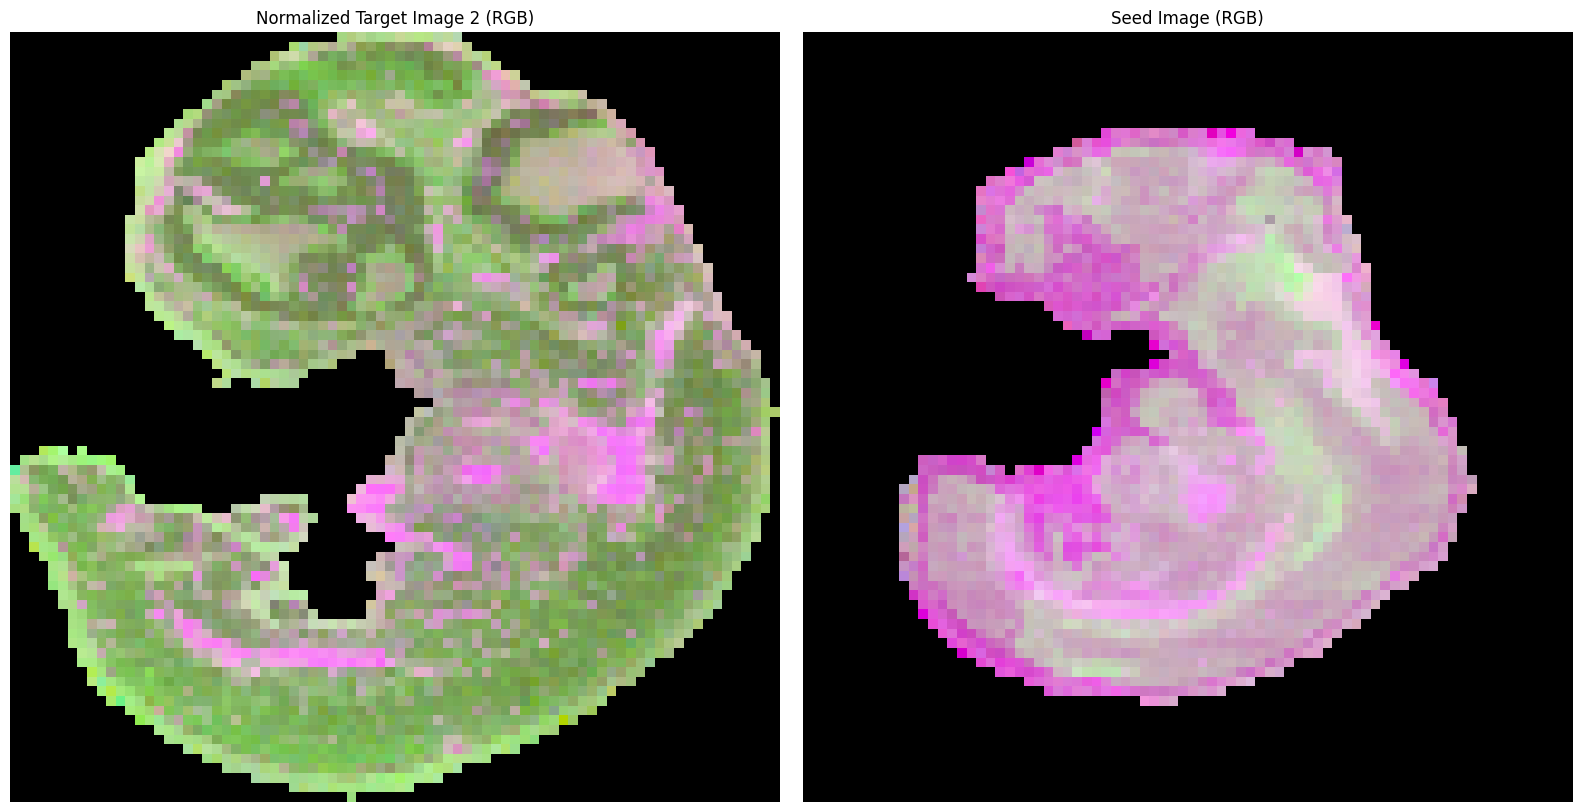

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(target_img_np2[..., :3])
axes[0].set_title("Normalized Target Image 2 (RGB)")
axes[0].axis("off")

axes[1].imshow(seed[..., :3])
axes[1].set_title("Seed Image (RGB)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

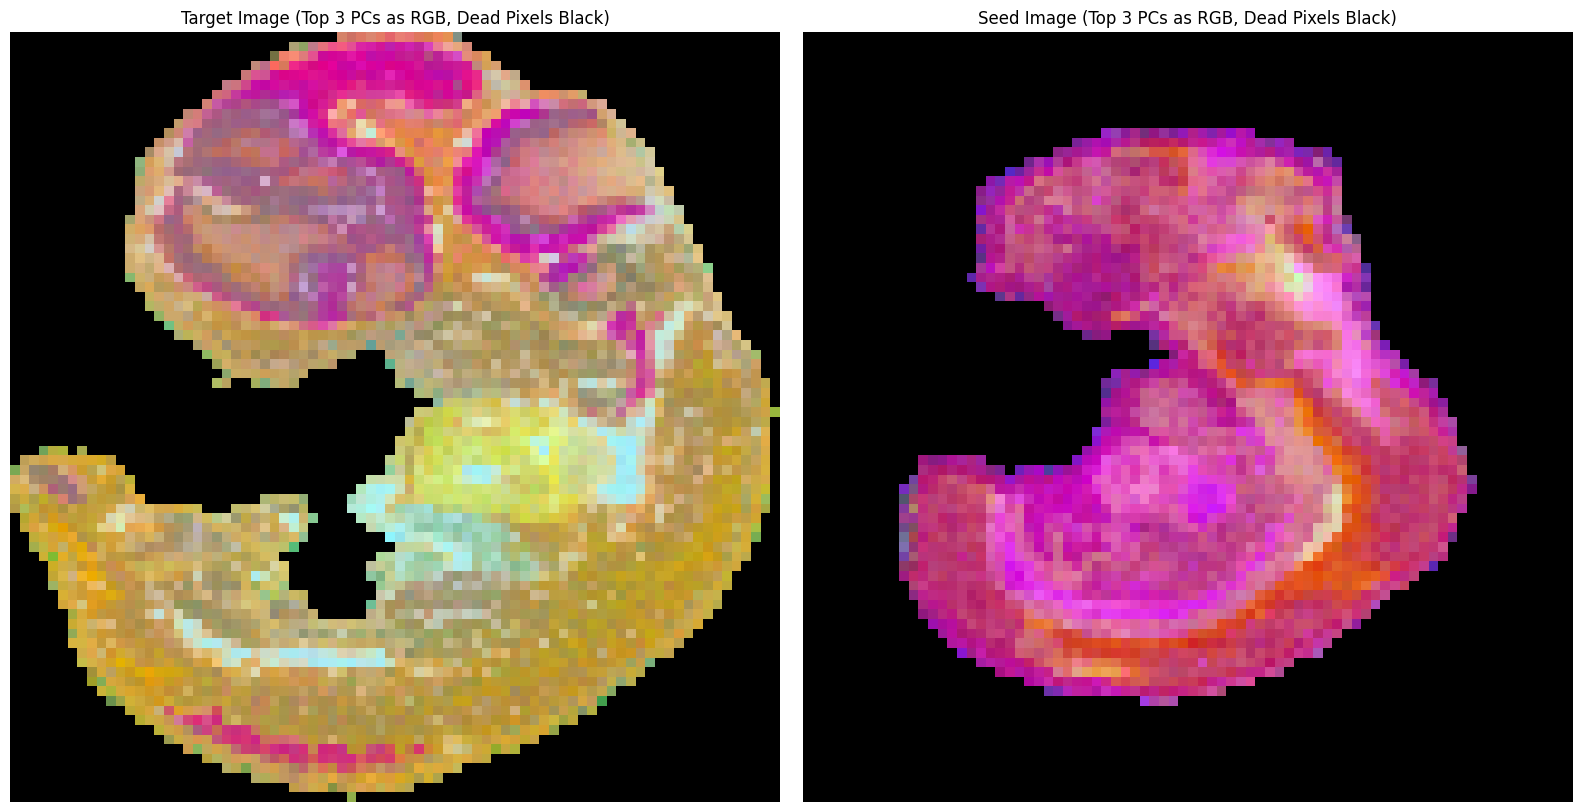

In [6]:
from sklearn.decomposition import PCA

# Compute PCA for target_img_np2
target_channels = target_img_np2.reshape(-1, target_img_np2.shape[-1])  # Flatten spatial dimensions
pca_target = PCA(n_components=3)
pcs_target = pca_target.fit_transform(target_channels).reshape(target_img_np2.shape[:2] + (3,))  # Reshape back to spatial dimensions

# Normalize the top 3 PCs for target_img_np2
pcs_target_normalized = (pcs_target - pcs_target.min(axis=(0, 1), keepdims=True)) / (
    pcs_target.max(axis=(0, 1), keepdims=True) - pcs_target.min(axis=(0, 1), keepdims=True) + 1e-8
)

# Apply threshold to determine "dead" pixels in target_img_np2
alive_mask_target = target_img_np2[..., -1] >= 0.1  # Assuming the last channel is the alpha channel
pcs_target_normalized[~alive_mask_target] = [0, 0, 0]  # Set dead pixels to black

# Compute PCA for seed
seed_channels = seed.reshape(-1, seed.shape[-1])  # Flatten spatial dimensions
pca_seed = PCA(n_components=3)
pcs_seed = pca_seed.fit_transform(seed_channels).reshape(seed.shape[:2] + (3,))  # Reshape back to spatial dimensions

# Normalize the top 3 PCs for seed
pcs_seed_normalized = (pcs_seed - pcs_seed.min(axis=(0, 1), keepdims=True)) / (
    pcs_seed.max(axis=(0, 1), keepdims=True) - pcs_seed.min(axis=(0, 1), keepdims=True) + 1e-8
)

# Apply threshold to determine "dead" pixels in seed
alive_mask_seed = seed[..., -1] >= 0.1  # Assuming the last channel is the alpha channel
pcs_seed_normalized[~alive_mask_seed] = [0, 0, 0]  # Set dead pixels to black

# Plot the images
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(pcs_target_normalized)
axes[0].set_title("Target Image (Top 3 PCs as RGB, Dead Pixels Black)")
axes[0].axis("off")

axes[1].imshow(pcs_seed_normalized)
axes[1].set_title("Seed Image (Top 3 PCs as RGB, Dead Pixels Black)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [7]:
import matplotlib.pyplot as plt
import random
import torch
import torch.optim.lr_scheduler as sched
import torch.optim as optim
import torch.cuda.amp as amp
import torch.nn.functional as F

model = CAModel(
    n_genes=n_genes, 
    hidden_channels=hidden_channels
).to(device)
# Generate random seed for the cellular automaton
h, w = target_img_np2.shape[:2]  # h, w from the actual target image

target_tensor2 = torch.tensor(target_img_np2, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)  # Move to GPU
seed_tensor = torch.tensor(seed, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

base_lr = 2e-3
t_warm = 2000  # steps 0 … 999
t_plateau = 0  # No plateau phase
t_total = 4000  # training ends at 4000

optimizer = optim.Adam(model.parameters(), lr=base_lr)

# --- phase 1: warm-up -------------------------------------------------
warmup_sched = sched.LinearLR(
    optimizer,
    start_factor=0.5,         # 0.5 × base_lr → base_lr
    end_factor=1.0,
    total_iters=t_warm
)

# --- phase 2: flat plateau -------------------------------------------
plateau_sched = sched.ConstantLR(
    optimizer,
    factor=1.0,               # keep at base_lr
    total_iters=t_plateau - t_warm
)

# --- phase 3: cosine decay -------------------------------------------
cosine_sched = sched.CosineAnnealingLR(
    optimizer,
    T_max=t_total - t_plateau,  # number of decay steps
    eta_min=base_lr * 0.1
)

# Chain them together
scheduler = sched.SequentialLR(
    optimizer,
    schedulers=[warmup_sched, plateau_sched, cosine_sched],
    milestones=[t_warm, t_plateau]       # step indices where we switch
)

num_epochs = 4000  # Adjust as needed
loss_log = []
loss_channels = model.n_genes + 1

# Initialize GradScaler for mixed precision
scaler = amp.GradScaler()

# Create a pool of 30 seeds
seed_pool = [torch.tensor(seed, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device) for _ in range(30)]

# Batch size
batch_size = 5

for epoch in range(num_epochs):
    # Randomly select a batch of seeds from the pool
    seed_batch_indices = random.sample(range(len(seed_pool)), batch_size)  # Indices of selected seeds
    seed_batch = torch.cat([seed_pool[i] for i in seed_batch_indices], dim=0)  # Shape: [batch_size, channels, height, width]
    current_state = seed_batch.clone()

    random_int = random.randint(100, 125)
    for _ in range(random_int):
        with amp.autocast():
            current_state = model(current_state)  # Process batch of seeds in mixed precision

    # Compute loss for the batch
    target_batch = target_tensor2.expand(batch_size, -1, -1, -1)[:, :loss_channels]
    with amp.autocast():
        per_sample_losses = F.mse_loss(current_state[:, :loss_channels], target_batch, reduction='none').mean(dim=(1, 2, 3))  # Shape: [batch_size]
        losses = per_sample_losses.mean()  # Scalar mean over batch
    total_loss = losses

    # Find the index of the highest loss in the batch
    highest_loss_idx = torch.argmax(per_sample_losses).item()

    optimizer.zero_grad()
    scaler.scale(total_loss).backward()
    
    # Gradient clipping to prevent exploding gradients
    for p in model.parameters():
        if p.grad is not None:
            g_norm = p.grad.data.norm()
            if g_norm > 1:
                p.grad.data /= g_norm

    scaler.step(optimizer)
    scaler.update()
    scheduler.step()
    loss_log.append(total_loss.item())

    # Update the seed pool
    for i, idx in enumerate(seed_batch_indices):
        if i == highest_loss_idx:
            # Replace the seed with the highest loss with the original seed
            seed_pool[idx] = torch.tensor(seed, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
        else:
            # Update the seed pool with the model's output
            seed_pool[idx] = current_state[i].unsqueeze(0).detach()  # Detach to avoid gradient tracking

    # Print loss
    if (epoch + 1) % 1 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {total_loss.item():.4f}')

/tmp/ipykernel_2562590/2803553758.py:60: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/tmp/ipykernel_2562590/2803553758.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/tmp/ipykernel_2562590/2803553758.py:81: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


Epoch 1/4000, Loss: 0.1710
Epoch 2/4000, Loss: 0.1674
Epoch 3/4000, Loss: 0.1610
Epoch 4/4000, Loss: 0.1567
Epoch 5/4000, Loss: 0.1555
Epoch 6/4000, Loss: 0.1536
Epoch 7/4000, Loss: 0.1528
Epoch 8/4000, Loss: 0.1512
Epoch 9/4000, Loss: 0.1457
Epoch 10/4000, Loss: 0.1445
Epoch 11/4000, Loss: 0.1330
Epoch 12/4000, Loss: 0.1317
Epoch 13/4000, Loss: 0.1284
Epoch 14/4000, Loss: 0.1310
Epoch 15/4000, Loss: 0.1312
Epoch 16/4000, Loss: 0.1288
Epoch 17/4000, Loss: 0.1305
Epoch 18/4000, Loss: 0.1251
Epoch 19/4000, Loss: 0.1348
Epoch 20/4000, Loss: 0.1301
Epoch 21/4000, Loss: 0.1297
Epoch 22/4000, Loss: 0.1323
Epoch 23/4000, Loss: 0.1309
Epoch 24/4000, Loss: 0.1294
Epoch 25/4000, Loss: 0.1340
Epoch 26/4000, Loss: 0.1312
Epoch 27/4000, Loss: 0.1285
Epoch 28/4000, Loss: 0.1292
Epoch 29/4000, Loss: 0.1302
Epoch 30/4000, Loss: 0.1271
Epoch 31/4000, Loss: 0.1255
Epoch 32/4000, Loss: 0.1310
Epoch 33/4000, Loss: 0.1307
Epoch 34/4000, Loss: 0.1287
Epoch 35/4000, Loss: 0.1282
Epoch 36/4000, Loss: 0.1278
E

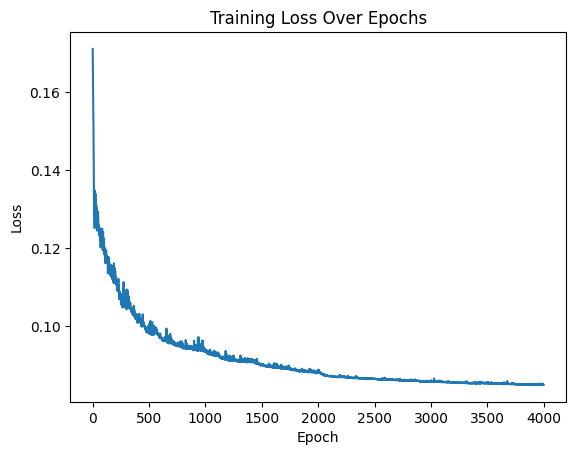

In [8]:
plt.plot(loss_log)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show()

In [10]:
torch.save(model.state_dict(), "batches_model.pth")

In [11]:
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import glob

model.eval()  # Set the model to evaluation mode
# Create a folder to save images
output_folder = "frames_pca"
os.makedirs(output_folder, exist_ok=True)

# Initialize the seed tensor
inference_seed = seed_tensor.clone().to(device)

# Run the simulation and save images every 10 steps
for i in range(125):
    with torch.no_grad():
        inference_seed = model(inference_seed)
    
    # Extract all channels and compute the top 3 principal components
    channels = inference_seed[0].detach().cpu().numpy().transpose(1, 2, 0).reshape(-1, inference_seed.shape[1])  # Flatten spatial dimensions
    pca = PCA(n_components=3)
    pcs = pca.fit_transform(channels).reshape(inference_seed.shape[2], inference_seed.shape[3], 3)  # Reshape back to spatial dimensions
    
    # Normalize the top 3 PCs to [0, 1] for visualization
    pcs_normalized = (pcs - pcs.min(axis=(0, 1), keepdims=True)) / (pcs.max(axis=(0, 1), keepdims=True) - pcs.min(axis=(0, 1), keepdims=True) + 1e-8)
    
    # Apply threshold to determine "dead" pixels (alpha channel or other criteria)
    alive_mask = inference_seed[0, -1].detach().cpu().numpy() >= 0.1  # Assuming the last channel is the alpha channel
    pcs_normalized[~alive_mask] = [0, 0, 0]  # Set dead pixels to black
    
    # Use the top 3 PCs as the RGB representation
    rgb = pcs_normalized
    
    # Save the frame
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(f"Step {i}")
    plt.savefig(os.path.join(output_folder, f"frame_{i:03d}.png"), bbox_inches="tight")
    plt.close()

# Create and save the GIF
input_folder = "frames_pca"
output_gif = "pca_batch.gif"

# Get all image files in the folder, sorted by filename
image_files = sorted(glob.glob(os.path.join(input_folder, "frame_*.png")))

# Load images into a list
frames = [Image.open(img) for img in image_files]

# Create and save the GIF
frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=125,  # Duration between frames in milliseconds
    loop=0         # Loop forever (set to 1 for looping once)
)